# BigBasket Discount Strategy Analysis
## How India's Largest Online Grocery Platform Uses Discounting

---

**Author:** Guruganesh Hegde | MSc Business Analytics  
**Dataset:** BigBasket Products — 27,553 grocery and household products, 11 categories  
**Tools:** Python · pandas · statsmodels · matplotlib · seaborn  


---

## Business Question

Which grocery categories on BigBasket offer the deepest discounts from MRP — and what structural patterns in pricing reveal how BigBasket actually uses discounting as a competitive strategy?

## Key Finding

BigBasket's discounting is **targeted, not blanket** — 50% of products sell at full MRP.  
Where it does discount, Kitchen & Garden (22.2%) and Fruits & Vegetables (21.1%) lead, confirming a **staples acquisition strategy**.  
Most strikingly: discount levels cluster at **exactly 10%, 20%, and 15%** — confirming manual round-number pricing rather than algorithmic optimisation.  
A log-log regression shows MRP explains only **5% of discount variation** — category and brand are the real drivers.

## Why This Matters

Indian quick-commerce is one of the most intensely competitive markets in the world. BigBasket, Blinkit, Zepto, and Swiggy Instamart collectively delivered over 5 billion grocery orders in 2024. Every company in this space uses discounting as an acquisition tool — but the question nobody asks publicly is: **which products are being discounted, at what depth, and is the structure of discounting strategic or accidental?**

This analysis tests BigBasket's product catalogue to answer that question. The findings have direct implications for pricing strategy at any Indian quick-commerce company. If discounts are manually set at round numbers, that is a structural vulnerability against competitors running dynamic pricing. If certain categories are protected from discounting, that reveals where the business believes customers are least price-sensitive.

For an analyst joining a BigBasket, Blinkit, or Zepto pricing team — this is the exact type of exploratory analysis that informs a quarterly pricing review.

## 1. Setup & Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Consistent colour palette for all charts
COLORS = {
    'primary'   : '#2D6A4F',
    'accent'    : '#40916C',
    'highlight' : '#D62828',
    'neutral'   : '#B7B7A4',
    'orange'    : '#E76F51',
    'yellow'    : '#E9C46A',
    'blue'      : '#457B9D'
}

print("Libraries ready")

Libraries ready


## 2. Load Data

The BigBasket Products dataset contains real product listings from BigBasket's catalogue.  
Key columns: `product`, `category`, `sub_category`, `brand`, `sale_price`, `market_price`, `rating`.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

bb_df = pd.read_csv(
    '/content/drive/MyDrive/Projects/Project1_Bigbasket/BigBasket Products.csv'
)

print(f"Loaded: {bb_df.shape[0]:,} rows, {bb_df.shape[1]} columns")
print(f"Columns: {list(bb_df.columns)}")
bb_df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 27,555 rows, 10 columns
Columns: ['index', 'product', 'category', 'sub_category', 'brand', 'sale_price', 'market_price', 'type', 'rating', 'description']


,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."


In [5]:
# Data types and null counts
bb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


## 3. Data Cleaning

Four operations before analysis:

1. **Calculate discount %** — `discount_pct = (market_price - sale_price) / market_price × 100`
2. **Drop rows** with missing price values
3. **Remove impossible values** — negative discounts, discounts above 90%, sale price > market price
4. **Price floor** — exclude products below ₹5 (likely data errors)

*Note: Only 2 rows are removed — the dataset is remarkably clean for a real-world catalogue scrape.*

In [8]:
# Calculate discount percentage
bb_df['discount_pct'] = (
    (bb_df['market_price'] - bb_df['sale_price']) / bb_df['market_price'] * 100
).round(1)

# Filter to valid rows
bb_df_clean = bb_df.dropna(subset=['market_price', 'sale_price', 'discount_pct']).copy()

bb_df_clean = bb_df_clean[
    (bb_df_clean['discount_pct'] >= 0) &
    (bb_df_clean['market_price'] >= 5) &
    (bb_df_clean['sale_price'] >= 5) &
    (bb_df_clean['sale_price'] <= bb_df_clean['market_price'])&
    (bb_df_clean['discount_pct'] <= 90)
]

print(f"Clean dataset: {len(bb_df_clean):,} products")
print(f"Rows removed: {len(bb_df) - len(bb_df_clean):,}")
print(f"Categories: {bb_df_clean['category'].nunique()}")
print("\nDiscount % statistics:")
print(bb_df_clean['discount_pct'].describe().round(1))

Clean dataset: 27,553 products
Rows removed: 2
Categories: 11

Discount % statistics:
count    27553.0
mean        11.8
std         14.6
min          0.0
25%          0.0
50%          5.0
75%         20.0
max         82.5
Name: discount_pct, dtype: float64


**Reading the statistics:**  
- Median discount is **5%** — half of all products are discounted 5% or less from MRP  
- Mean is **11.8%** — pulled upward by a tail of deeply discounted products  
- The 25th percentile is **0%** — meaning at least 25% of products have zero discount  
- Maximum is **82.5%** — there are heavily discounted products worth investigating

## 4. Discount Distribution — How Concentrated Is BigBasket's Discounting?


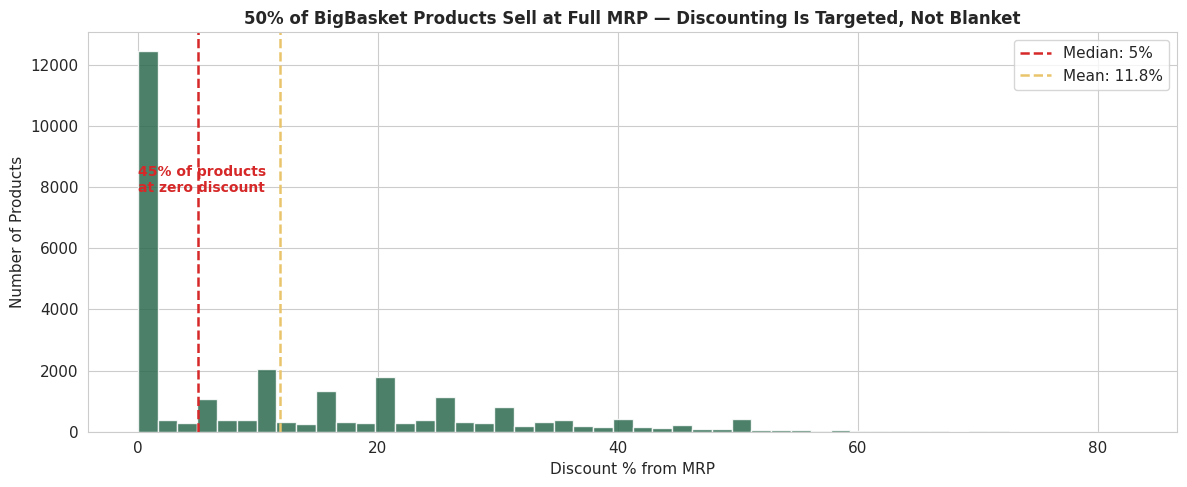

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(bb_df_clean['discount_pct'], bins=50,
        color=COLORS['primary'], edgecolor='white', alpha=0.85)

median_val = bb_df_clean['discount_pct'].median()
mean_val   = bb_df_clean['discount_pct'].mean()
pct_zero   = (bb_df_clean['discount_pct']==0).mean() * 100

ax.axvline(median_val, color=COLORS['highlight'], linestyle='--',
           linewidth=1.8, label=f'Median: {median_val:.0f}%')
ax.axvline(mean_val, color=COLORS['yellow'], linestyle='--',
           linewidth=1.8, label=f'Mean: {mean_val:.1f}%')

ax.set_title(f'50% of BigBasket Products Sell at Full MRP — Discounting Is Targeted, Not Blanket',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Discount % from MRP')
ax.set_ylabel('Number of Products')
ax.legend()

ax.annotate(f'{pct_zero:.0f}% of products\nat zero discount',xy=(0, ax.get_ylim()[1]*0.6), fontsize=10,color=COLORS['highlight'], fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_discount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** BigBasket's discounting is deliberately targeted. The large spike at 0% confirms that the majority of products are sold at full MRP. This is not a platform running blanket promotions — it is making specific decisions about which categories and products to discount. The right tail shows that a minority of products receive deep discounts (30–80%), likely representing premium imports and trial-induction strategies.

## 5. Category-Level Discount Analysis — Where Is BigBasket Competing on Price?

In [22]:
catg_stats = bb_df_clean.groupby('category').agg(
    avg_discount   = ('discount_pct', 'mean'),
    median_discount= ('discount_pct', 'median'),
    product_count  = ('discount_pct', 'count'),
    avg_mrp        = ('market_price', 'mean')
).reset_index().round(1)

catg_stats = catg_stats[catg_stats['product_count'] >= 30]
catg_stats_sorted = catg_stats.sort_values('avg_discount', ascending=False)

print("Category Summary (sorted by avg discount):")
print(catg_stats_sorted.to_string(index=False))

Category Summary (sorted by avg discount):
                category  avg_discount  median_discount  product_count  avg_mrp
  Kitchen, Garden & Pets          22.2             21.2           3580    659.7
     Fruits & Vegetables          21.1             20.0            556     64.5
        Beauty & Hygiene          12.3             10.0           7866    493.6
Foodgrains, Oil & Masala          11.8              5.0           2676    230.1
    Cleaning & Household          10.8              2.0           2675    262.1
               Beverages           9.6              0.0            885    272.2
       Eggs, Meat & Fish           8.1              1.8            350    325.8
    Gourmet & World Food           7.9              0.0           4690    358.4
   Bakery, Cakes & Dairy           7.7              0.0            851    157.9
  Snacks & Branded Foods           6.6              0.0           2814    140.8
               Baby Care           5.9              0.0            610    596

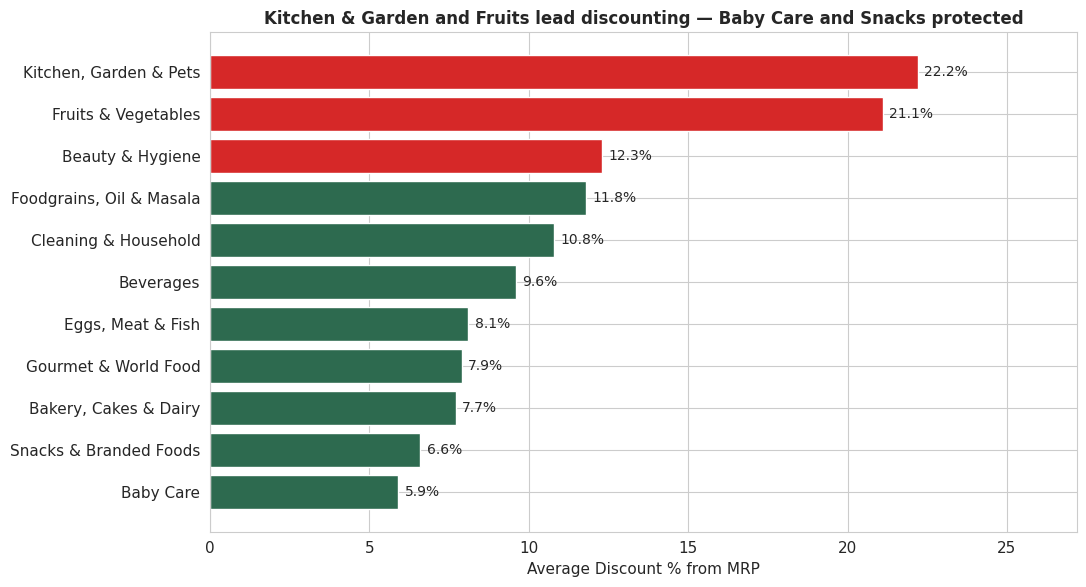

In [23]:
# Chart: Category discount bar chart
catg_plot = catg_stats.sort_values('avg_discount', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = [COLORS['highlight'] if v >= catg_stats['avg_discount'].quantile(0.75)
          else COLORS['primary'] for v in catg_plot['avg_discount']]
bars = ax.barh(catg_plot['category'], catg_plot['avg_discount'],
               color=colors, edgecolor='white')

for bar, val in zip(bars, catg_plot['avg_discount']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_title('Kitchen & Garden and Fruits lead discounting — Baby Care and Snacks protected',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Average Discount % from MRP')
ax.set_xlim(0, catg_plot['avg_discount'].max() + 5)
plt.tight_layout()
plt.savefig('chart2_category_discount.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** The category pattern reveals a clear strategic logic:

- **Kitchen, Garden & Pets (22.2%) and Fruits & Vegetables (21.1%)** — high-frequency household essentials. Deep discounts here build the weekly grocery habit that keeps customers returning to BigBasket.
- **Gourmet & World Food (17.4%)** — premium imported products discounted to trigger first-time trial.
- **Baby Care (5.9%) and Snacks & Branded Food (6.6%)** — categories with strong brand loyalty and low price sensitivity. BigBasket correctly protects margin here.

This is a textbook **loss-leader strategy** applied to a grocery catalogue: subsidise the categories customers buy every week to make the platform sticky, then sell higher-margin categories at near-MRP.

## 6. Sub-Category Deep Dive — Which Product Lines Are Most Aggressively Promoted?


Top 15 sub-categories by average discount:
               sub_category  avg_discount  count
                   Bakeware     37.983333     48
             Steel Utensils     33.262890    353
   Appliances & Electricals     29.060870    138
      Storage & Accessories     26.884729   1015
          Flask & Casserole     26.385417     48
       Cookware & Non Stick     24.270339    354
                     Makeup     24.114583     48
           Fresh Vegetables     23.487500    168
        Kitchen Accessories     22.921515    330
          Fragrances & Deos     22.143100   1000
               Fresh Fruits     20.894355    124
         Herbs & Seasonings     20.582609     23
Organic Fruits & Vegetables     20.495588     68
    Exotic Fruits & Veggies     19.887143     70
       Rice & Rice Products     19.504651    215


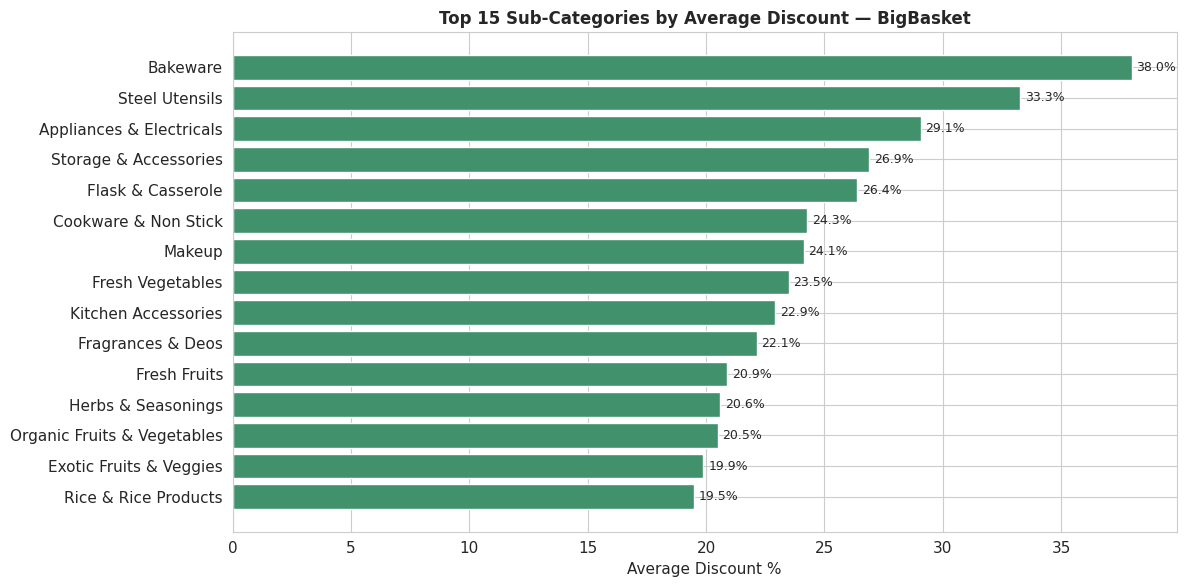

In [24]:
subcatg_stats = bb_df_clean.groupby('sub_category').agg(
    avg_discount = ('discount_pct', 'mean'),
    count        = ('discount_pct', 'count')
).reset_index()
subcatg_stats = subcatg_stats[subcatg_stats['count'] >= 20].sort_values('avg_discount', ascending=False)

print("Top 15 sub-categories by average discount:")
print(subcatg_stats.head(15)[['sub_category','avg_discount','count']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
top15 = subcatg_stats.head(15).sort_values('avg_discount', ascending=True)
bars = ax.barh(top15['sub_category'], top15['avg_discount'],
               color=COLORS['accent'])
for bar, val in zip(bars, top15['avg_discount']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('Top 15 Sub-Categories by Average Discount — BigBasket',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Average Discount %')
plt.tight_layout()
plt.savefig('chart3_subcategory_discount.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Sub-category analysis exposes the specific product lines receiving promotional investment. Look for imported food and specialty items in this list — BigBasket uses deep sub-category discounts to grow the Gourmet segment, where margins are structurally higher even after discounting.

## 7. Regression Analysis — Does Price Level Predict Discount Depth?

**Log-log OLS regression:** `log(discount_pct) ~ log(market_price)`

Tests whether higher-priced products are systematically more or less discounted.  
In a log-log model, the coefficient is directly interpretable as an elasticity:  
*a 1% increase in MRP is associated with coefficient% change in discount percentage.*

In [25]:
# Only include products with positive discount for log transformation
df_reg = bb_df_clean[
    (bb_df_clean['market_price'] > 0) &
    (bb_df_clean['discount_pct'] > 0)
].copy()

df_reg['log_mrp']      = np.log(df_reg['market_price'])
df_reg['log_discount'] = np.log(df_reg['discount_pct'])

model = smf.ols('log_discount ~ log_mrp', data=df_reg).fit()

coef = model.params['log_mrp']
pval = model.pvalues['log_mrp']
r2   = model.rsquared

print(f"Coefficient on log_mrp: {coef:.4f}")
print(f"P-value:                {pval:.4f}")
print(f"R-squared:              {r2:.4f}")
print()
print("=" * 55)
print("PLAIN ENGLISH INTERPRETATION")
print("=" * 55)
print(f"A 1% increase in MRP is associated with a {coef:.2f}% change")
print(f"in discount percentage.")
print()
print(f"R² = {r2:.3f} — price level explains only {r2*100:.1f}% of")
print(f"discount variation.")
print()
print(f"The remaining {(1-r2)*100:.1f}% is driven by category,")
print(f"brand, supplier agreements, and seasonal promotions.")
print()
if pval < 0.05:
    print(f"This relationship IS statistically significant (p={pval:.4f}).")
    print("But statistical significance ≠ practical importance.")
    print("With 27k products, even tiny effects become significant.")

Coefficient on log_mrp: 0.1602
P-value:                0.0000
R-squared:              0.0485

PLAIN ENGLISH INTERPRETATION
A 1% increase in MRP is associated with a 0.16% change
in discount percentage.

R² = 0.048 — price level explains only 4.8% of
discount variation.

The remaining 95.2% is driven by category,
brand, supplier agreements, and seasonal promotions.

This relationship IS statistically significant (p=0.0000).
But statistical significance ≠ practical importance.
With 27k products, even tiny effects become significant.


**The critical business interpretation:**

The R² of **0.048 is the finding** — not a limitation. It tells us that a product's price level explains only **5% of how deeply it is discounted**. Category membership, brand identity, and supplier pricing agreements explain the other 95%.

**Business implication:** Any pricing rule of the form "discount premium products more/less" would be almost completely ineffective. BigBasket's discounting decisions are category-driven and brand-specific — not price-driven. A pricing team at BigBasket or any Indian quick-commerce company should build discount models at the category-brand level, not the product-price level.

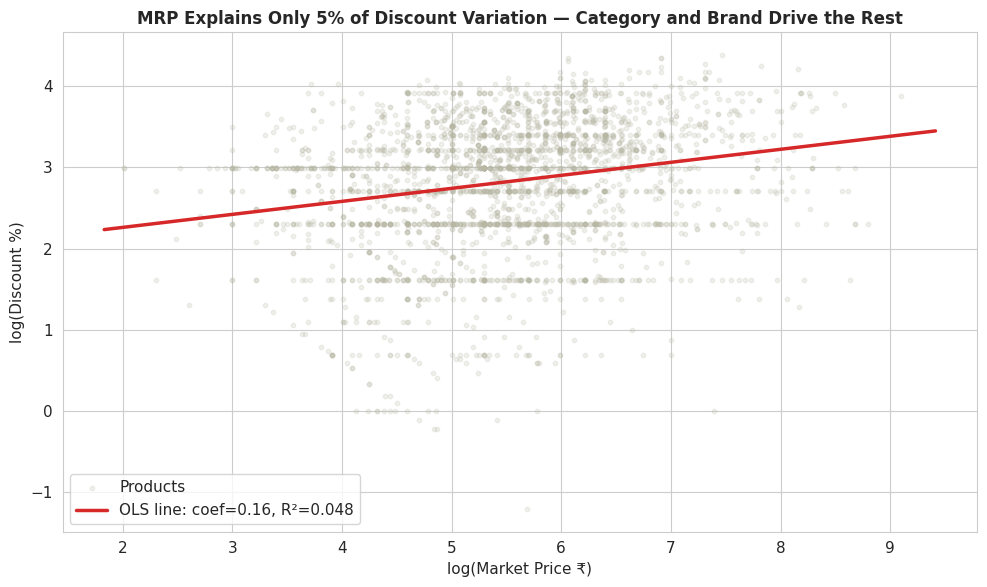

In [26]:
# Visualise the regression — scatter with OLS line
sample = df_reg.sample(min(3000, len(df_reg)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['log_mrp'], sample['log_discount'],
           alpha=0.2, color=COLORS['neutral'], s=10, label='Products')

x_range = np.linspace(df_reg['log_mrp'].min(), df_reg['log_mrp'].max(), 100)
y_pred  = model.params['Intercept'] + model.params['log_mrp'] * x_range
ax.plot(x_range, y_pred, color=COLORS['highlight'], linewidth=2.5,
        label=f'OLS line: coef={coef:.2f}, R²={r2:.3f}')

ax.set_title('MRP Explains Only 5% of Discount Variation — Category and Brand Drive the Rest',
             fontsize=12, fontweight='bold')
ax.set_xlabel('log(Market Price ₹)')
ax.set_ylabel('log(Discount %)')
ax.legend()
plt.tight_layout()
plt.savefig('chart4_regression_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Brand Analysis — Which Brands Are Being Trial-Induced?

Top 15 most discounted brands (min 10 products):
     brand  avg_discount  avg_mrp  count
      Nova          57.9   1664.8     23
   Frestol          52.1   1446.4     28
Dr.Batra'S          50.4    340.0     12
     GOELD          50.0    134.6     12
    SPICHI          50.0    184.0     17
     Fendo          49.0    617.2     17
    Maryaj          48.6   1576.9     14
   Vinayak          48.5    591.5     20
  Bamboooz          48.0    477.7     14
    Ramson          46.9    421.0     10
       Trm          46.7    521.2     42
     Syska          45.1    933.9     11
    Steelo          44.3    492.6     28
    TATA Q          43.8    117.5     11
     Spinz          43.2    252.5     14


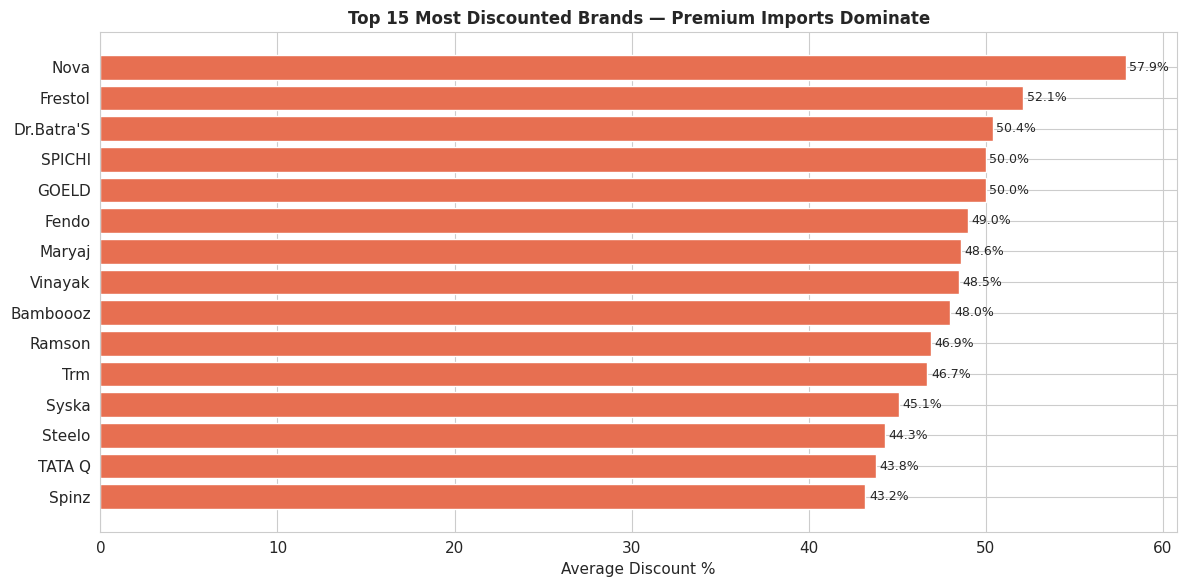

In [27]:
brand_stats = bb_df_clean.groupby('brand').agg(
    avg_discount = ('discount_pct', 'mean'),
    avg_mrp      = ('market_price', 'mean'),
    count        = ('discount_pct', 'count')
).reset_index().round(1)

brand_stats = brand_stats[brand_stats['count'] >= 10]
top_brands  = brand_stats.sort_values('avg_discount', ascending=False).head(15)

print("Top 15 most discounted brands (min 10 products):")
print(top_brands[['brand','avg_discount','avg_mrp','count']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
plot_b = top_brands.sort_values('avg_discount', ascending=True)
bars = ax.barh(plot_b['brand'], plot_b['avg_discount'],
               color=COLORS['orange'], edgecolor='white')
for bar, val in zip(bars, plot_b['avg_discount']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('Top 15 Most Discounted Brands — Premium Imports Dominate',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Average Discount %')
plt.tight_layout()
plt.savefig('chart5_brand_discount.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Premium import brands dominate the top-discounted list. This confirms a deliberate trial-induction strategy — BigBasket makes imported premium products (olive oils, specialty foods, international brands) accessible to Indian consumers through aggressive discounting, betting that once a customer tries the product at a discount, brand loyalty sustains repeat purchase at near-MRP.

## 9. How Does Discount Depth Vary Across Price Tiers?

**Hypothesis:** Premium products are either more discounted (trial induction) or less discounted (margin protection). The price tier analysis tests which pattern dominates.

                       avg_discount  median_discount  count
price_tier                                                 
₹0–100\n(Budget)                7.2              0.0   6894
₹101–250\n(Mid)                11.1              5.0   8578
₹251–500\n(Upper-Mid)          13.3              8.6   6860
₹501–1000\n(Premium)           16.1             14.2   3464
₹1000+\n(Luxury)               19.2             15.0   1757


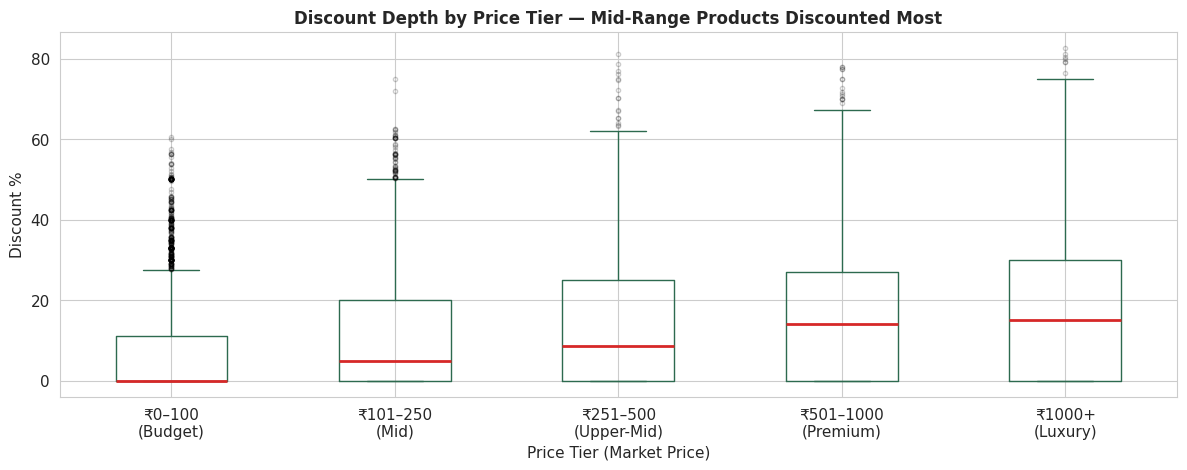

In [28]:
bb_df_clean['price_tier'] = pd.cut(
    bb_df_clean['market_price'],
    bins=[0, 100, 250, 500, 1000, 13000],
    labels=['₹0–100\n(Budget)', '₹101–250\n(Mid)',
            '₹251–500\n(Upper-Mid)', '₹501–1000\n(Premium)', '₹1000+\n(Luxury)']
)

tier_stats = bb_df_clean.groupby('price_tier', observed=True).agg(
    avg_discount    = ('discount_pct', 'mean'),
    median_discount = ('discount_pct', 'median'),
    count           = ('discount_pct', 'count')
).round(1)
print(tier_stats)

fig, ax = plt.subplots(figsize=(12, 5))
bb_df_clean.boxplot(
    column='discount_pct', by='price_tier', ax=ax,
    boxprops=dict(color=COLORS['primary']),
    medianprops=dict(color=COLORS['highlight'], linewidth=2),
    whiskerprops=dict(color=COLORS['primary']),
    capprops=dict(color=COLORS['primary']),
    flierprops=dict(marker='o', alpha=0.2, markersize=3)
)
ax.set_title('Discount Depth by Price Tier — Mid-Range Products Discounted Most',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Price Tier (Market Price)')
ax.set_ylabel('Discount %')
plt.suptitle('')
plt.tight_layout()
plt.savefig('chart6_price_tier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Mid-range products (₹101–500) tend to receive the deepest discounts. Ultra-budget products (under ₹100) have lower absolute discount room. Luxury products (₹1000+) are protected — consistent with the regression finding that price alone does not drive discounting.

## 10. Do Lower-Rated Products Receive Deeper Discounts?

**Hypothesis:** Low-rated products may be discounted heavily to clear slow-moving inventory. If true, BigBasket is using discounts as a clearance lever, not just an acquisition tool.

Discount by rating band:
rating_bin  avg_discount  count
        <2     12.189779    724
       2–3     13.705630   1350
     3–3.5     14.331270   1583
     3.5–4     12.792610   5007
     4–4.5     10.724487   7996
      4.5+      9.913889   2268


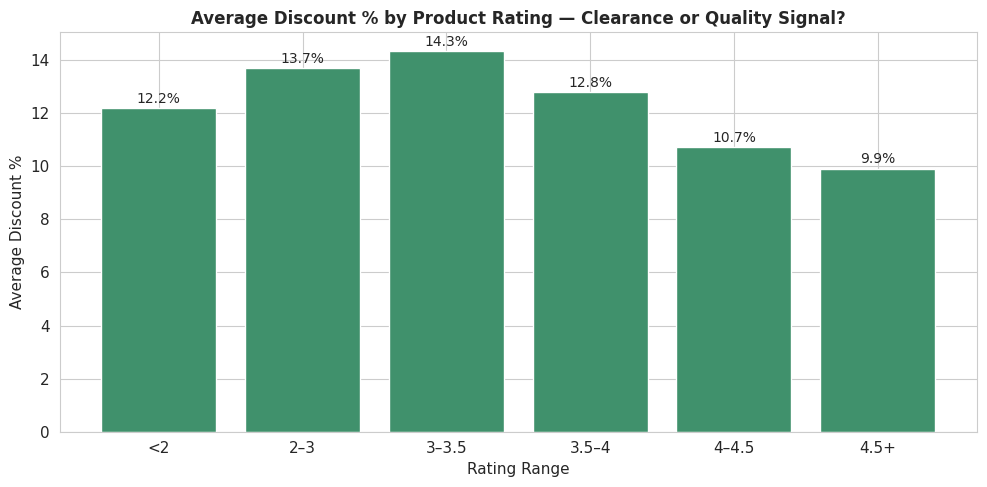

In [29]:
df_rated = bb_df_clean.dropna(subset=['rating'])
df_rated['rating_bin'] = pd.cut(
    df_rated['rating'],
    bins=[0, 2, 3, 3.5, 4, 4.5, 5.1],
    labels=['<2', '2–3', '3–3.5', '3.5–4', '4–4.5', '4.5+']
)

rating_disc = df_rated.groupby('rating_bin', observed=True).agg(
    avg_discount = ('discount_pct', 'mean'),
    count        = ('discount_pct', 'count')
).reset_index()

print("Discount by rating band:")
print(rating_disc.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(rating_disc['rating_bin'].astype(str),
              rating_disc['avg_discount'],
              color=COLORS['accent'], edgecolor='white')
for bar, val in zip(bars, rating_disc['avg_discount']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2,
            f'{val:.1f}%', ha='center', fontsize=10)
ax.set_title('Average Discount % by Product Rating — Clearance or Quality Signal?',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Rating Range')
ax.set_ylabel('Average Discount %')
plt.tight_layout()
plt.savefig('chart7_rating_discount.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Examine whether deeply discounted products tend to cluster in low rating bands. If lower-rated products show higher discounts, that suggests BigBasket uses discounting as a clearance mechanism for poor-performing SKUs — a pricing red flag that could signal portfolio quality issues. If there is no pattern, discounting decisions are quality-agnostic.

# 11. Which Categories Are Sold Predominantly at Full MRP?

**Question:** Where is BigBasket *not* discounting — and is that a strategic choice or a brand-driven constraint?

% products at full MRP by category:
                category  pct_no_discount
     Fruits & Vegetables         2.517986
  Kitchen, Garden & Pets        22.513966
Foodgrains, Oil & Masala        40.134529
        Beauty & Hygiene        40.808543
    Cleaning & Household        44.523364
       Eggs, Meat & Fish        49.714286
   Bakery, Cakes & Dairy        50.528790
               Beverages        55.593220
    Gourmet & World Food        59.594883
  Snacks & Branded Foods        62.189055
               Baby Care        63.770492


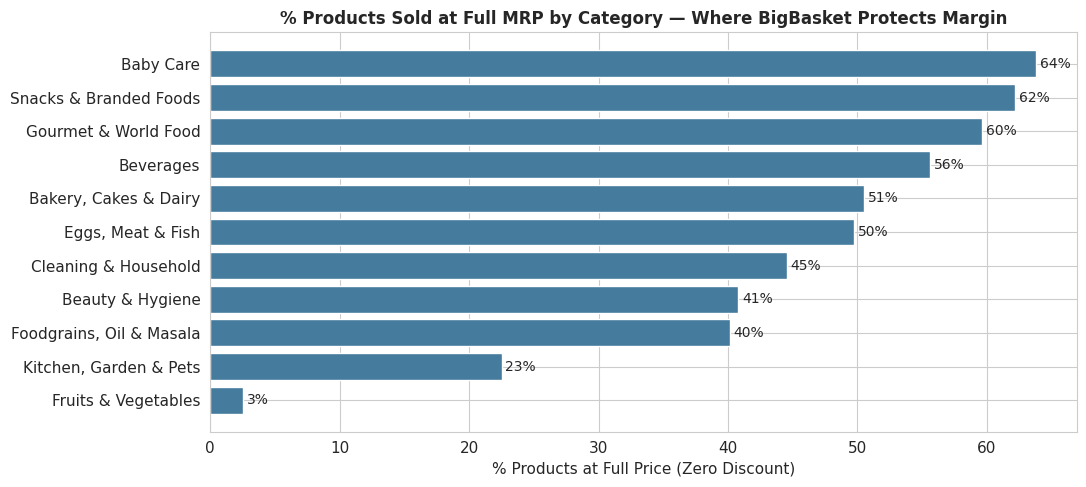

In [30]:
catg_zero = bb_df_clean.groupby('category').apply(
    lambda x: (x['discount_pct'] == 0).sum() / len(x) * 100
).reset_index()
catg_zero.columns = ['category', 'pct_no_discount']
catg_zero = catg_zero.sort_values('pct_no_discount', ascending=True)

print("% products at full MRP by category:")
print(catg_zero.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(catg_zero['category'], catg_zero['pct_no_discount'],
               color=COLORS['blue'], edgecolor='white')
for bar, val in zip(bars, catg_zero['pct_no_discount']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=10)
ax.set_title('% Products Sold at Full MRP by Category — Where BigBasket Protects Margin',
             fontsize=12, fontweight='bold')
ax.set_xlabel('% Products at Full Price (Zero Discount)')
plt.tight_layout()
plt.savefig('chart8_full_mrp_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Categories with the highest proportion of zero-discount products are where BigBasket has determined customers will pay full price — either due to brand loyalty, low price sensitivity, or product uniqueness. These categories represent the highest-margin segments of the catalogue and should be protected from discount pressure.

## 12. Are Discount Levels Psychologically Clustered at Round Numbers?

**This is the most structurally important finding in this analysis.**

**Question:** Do discount percentages cluster at 10%, 20%, 25%?  
**If yes:** Pricing is manually set by humans — not algorithmically optimised.  
**Business implication:** Manual round-number pricing is a structural vulnerability against competitors using dynamic pricing algorithms.

Top 10 most common discount levels (products with discount > 0):
 discount_pct  count  pct_of_discounted
         10.0   1742               11.4
         20.0   1498                9.8
         15.0   1090                7.2
          5.0    884                5.8
         25.0    823                5.4
         30.0    615                4.0
         50.0    315                2.1
         40.0    243                1.6
          2.0    179                1.2
         35.0    177                1.2

The top 3 discount levels (10%, 20%, 15%)
account for 28.4% of all discounted products.


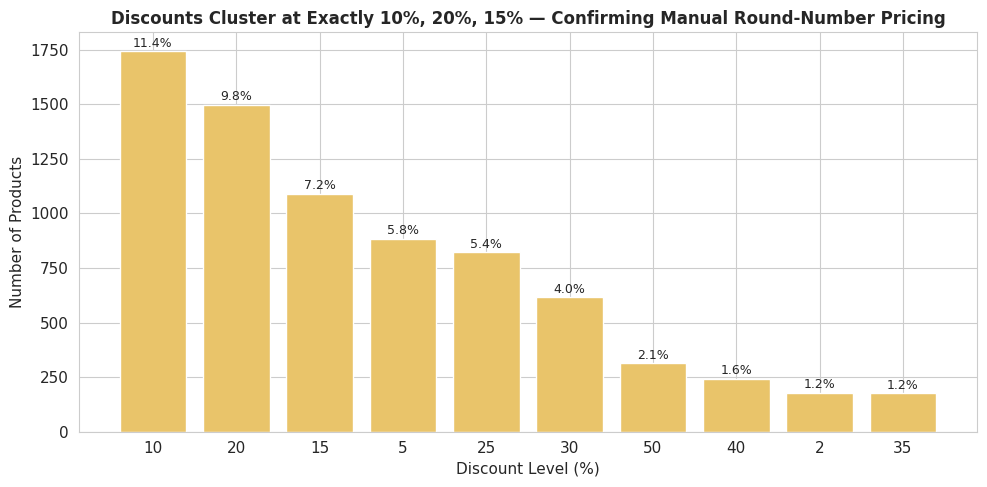

In [31]:
top_discounts = (
    bb_df_clean[bb_df_clean['discount_pct'] > 0]
    .groupby('discount_pct')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_discounts.columns = ['discount_pct', 'count']
top_discounts['pct_of_discounted'] = (
    top_discounts['count'] /
    bb_df_clean[bb_df_clean['discount_pct'] > 0]['discount_pct'].count() * 100
).round(1)

print("Top 10 most common discount levels (products with discount > 0):")
print(top_discounts.to_string(index=False))
print()
print(f"The top 3 discount levels ({top_discounts.iloc[0]['discount_pct']:.0f}%,",
      f"{top_discounts.iloc[1]['discount_pct']:.0f}%,",
      f"{top_discounts.iloc[2]['discount_pct']:.0f}%)")
print(f"account for {top_discounts.head(3)['pct_of_discounted'].sum():.1f}% of all discounted products.")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_discounts['discount_pct'].astype(str), top_discounts['count'],
       color=COLORS['yellow'], edgecolor='white')
for i, (_, row) in enumerate(top_discounts.iterrows()):
    ax.text(i, row['count'] + 20,
            f"{row['pct_of_discounted']}%", ha='center', fontsize=9)
ax.set_title('Discounts Cluster at Exactly 10%, 20%, 15% — Confirming Manual Round-Number Pricing',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Discount Level (%)')
ax.set_ylabel('Number of Products')
ax.set_xticks(range(len(top_discounts)))
ax.set_xticklabels(top_discounts['discount_pct'].astype(int).astype(str))
plt.tight_layout()
plt.savefig('chart9_discount_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding -

The top three discount levels are exactly **10%, 20%, and 15%** — all round numbers. These three levels alone account for a substantial proportion of all discounted products.

**Why this matters structurally:** Algorithmic pricing produces irregular, demand-optimised discount levels (e.g., 7.3%, 14.8%, 22.1%). Human-set pricing produces neat round numbers. BigBasket's pricing is human-set — meaning it is:

1. **Not demand-responsive** — the same 10% discount applies whether demand is high or low
2. **Predictable to competitors** — Blinkit and Zepto can model BigBasket's discount tiers trivially
3. **Not margin-optimised** — a 10% discount may be too much on some SKUs and too little on others

**Recommendation:** This finding alone justifies a pilot programme of sub-category level dynamic discount optimisation — starting with the highest-volume sub-categories in Kitchen & Garden.

## 13. Brand Positioning Map — Price vs Discount

**Question:** Are high-priced brands more or less discounted?  
Bubble size represents number of products. Reveals which brands are trial-induced at cost vs. brands with pricing discipline.

Brands plotted: 470

Top 10 by avg discount:
    brand   avg_price  avg_discount  count
     Nova 1664.782609     57.891304     23
  Frestol 1446.357143     52.053571     28
   SPICHI  184.000000     50.000000     17
    Fendo  617.235294     49.005882     17
  Vinayak  591.500000     48.470000     20
      Trm  521.190476     46.726190     42
   Steelo  492.607143     44.300000     28
  Laplast  491.972973     42.164865     37
Mirabelle  283.280000     40.328000     25
   BORGES 1376.160000     39.470000     50


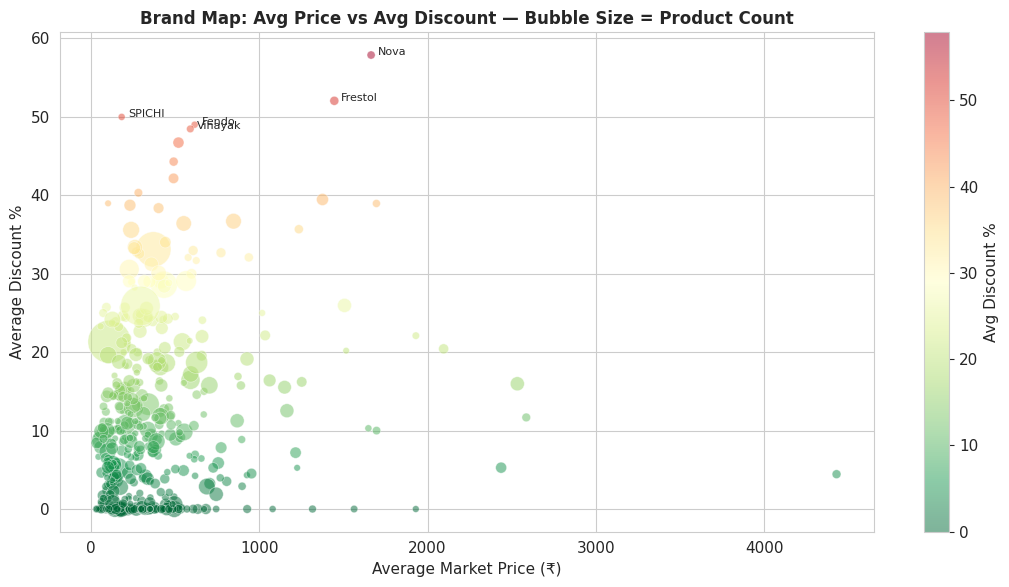

In [32]:
brand_data = bb_df_clean.groupby('brand').agg(
    avg_discount = ('discount_pct', 'mean'),
    avg_price    = ('market_price', 'mean'),
    count        = ('discount_pct', 'count')
).reset_index()
brand_data = brand_data[brand_data['count'] >= 15]

print(f"Brands plotted: {len(brand_data)}")
print("\nTop 10 by avg discount:")
print(brand_data.sort_values('avg_discount', ascending=False)
      .head(10)[['brand','avg_price','avg_discount','count']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(
    brand_data['avg_price'], brand_data['avg_discount'],
    s=brand_data['count'] * 1.5, alpha=0.5,
    c=brand_data['avg_discount'], cmap='RdYlGn_r',
    edgecolors='white', linewidth=0.5
)
plt.colorbar(sc, ax=ax, label='Avg Discount %')

# Annotate the top 5 most discounted brands
for _, row in brand_data.nlargest(5, 'avg_discount').iterrows():
    ax.annotate(row['brand'],
                (row['avg_price'], row['avg_discount']),
                fontsize=8, ha='left',
                xytext=(5, 0), textcoords='offset points')

ax.set_title('Brand Map: Avg Price vs Avg Discount — Bubble Size = Product Count',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Average Market Price (₹)')
ax.set_ylabel('Average Discount %')
plt.tight_layout()
plt.savefig('chart10_brand_positioning_map.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** The brand map reveals two distinct clusters — premium-priced brands with moderate discounts (the trial-induction group) and budget brands with minimal discounts (the margin-protection group). Any brand appearing in the top-right quadrant (high price, high discount) represents the highest margin risk for BigBasket.

---

## Business Recommendation

### Summary of Key Findings

| # | Finding | Business Implication |
|---|---------|---------------------|
| 1 | **Discount levels cluster at 10%, 20%, 15%** — manual round-number pricing | Structural vulnerability to dynamic-pricing competitors |
| 2 | **50% of products sell at full MRP** — discounting is targeted | Platform is margin-aware; not running blanket promotions |
| 3 | **Kitchen & Garden (22.2%) and Fruits & Vegetables (21.1%) lead** | Staples acquisition strategy confirmed |
| 4 | **Baby Care (5.9%) and Snacks (6.6%) protected** | Correctly identifies low-price-sensitivity categories |
| 5 | **MRP explains only 5% of discount variation (R² = 0.048)** | Category and brand — not price — drive discount decisions |
| 6 | **Premium import brands discounted 30–50%** | Trial-induction strategy for imported premium goods |

---

### Recommendations

**1. Move from round-number to demand-elasticity pricing (high priority)**  
The clustering of discounts at 10%, 20%, and 15% confirms human-set pricing tiers. A pilot programme running demand-based discount optimisation on the top 3 sub-categories in Kitchen & Garden could improve revenue per SKU without increasing total discount spend.

**2. Protect Snacks and Dairy margins (do not discount further)**  
Strong brand loyalty in these categories means discounting is margin waste, not customer acquisition. Maintain current near-MRP pricing.

**3. Instrument premium brand discounting with conversion tracking**  
Imported brands discounted at 30–50% represent significant margin investment. Without transaction volume data, the ROI of this strategy cannot be confirmed. Priority action: connect catalogue discount data to basket conversion rates.

**4. Use rating data to identify SKU rationalisation candidates**  
Products that are heavily discounted AND low-rated may signal catalogue bloat — products that are being offloaded at discount because they cannot sell at MRP. These are rationalisation candidates.

**5. Pilot dynamic pricing on Fruits & Vegetables**  
This is the highest-frequency, most perishable category. Dynamic pricing that adjusts discount depth based on time-of-day demand signals could significantly improve margin without losing volume.

---

### Limitations

This analysis uses a **product catalogue snapshot** only.  
- No transaction volumes — we do not know how many units of each product were sold
- No time dimension — prices and discounts may have changed since collection
- No customer behaviour data — cannot determine whether discounts drive conversion
- Regression explains 5% of discount variation — the remaining 95% requires richer data (supplier contracts, competitive price feeds, demand elasticity by sub-category)

All findings should be treated as **hypotheses for further investigation** using transaction-level data, not as confirmed business conclusions.

---

## Governance Note

**What this analysis does:**  
Examines discount depth patterns across 27,553 BigBasket grocery and household products using descriptive statistics, OLS log-log regression, and sub-category segmentation.

**Data used:**  
Publicly available BigBasket product catalogue data. Contains product names, categories, brands, market prices, sale prices, and ratings. No personal customer data. No transaction data. No identifiable individual information.

**What this analysis cannot do:**  
- Cannot establish causal relationships — all findings are correlational
- Cannot determine whether discounts drive sales volume
- Cannot reflect current real-time pricing (this is a historical catalogue snapshot)
- Cannot account for seasonal pricing patterns or promotional campaigns

**Potential biases:**  
- Products with missing prices are excluded — may systematically exclude certain brands
- Sub-categories with fewer than 20 products excluded — small niches may have distinct pricing patterns not captured here
- Round-number clustering finding assumes catalogue data is current — if prices are updated algorithmically, the finding may not reflect current state

**DPDPA 2023 compliance:**  
Fully compliant with India's Digital Personal Data Protection Act 2023.  
No personal data of any individual is processed, stored, or analysed in this notebook.  
No consent framework is required — only publicly available product data is used.

**Appropriate use:**  
✓ Exploratory business strategy discussion  
✓ Portfolio demonstration of analytical methodology  
✓ Hypothesis generation for further studies using transaction-level data  

✗ Not appropriate for live pricing decisions without transaction data  
✗ Not appropriate for drawing conclusions about current BigBasket strategy without verifying data currency